In [1]:
# from itertools import chain, combinations
from typing import Literal
# from collections import defaultdict, Counter
# from collections.abc import Iterable, Sequence
# import math
import pickle

import matplotlib.pyplot as plt
import numpy as np
# import pandas as pd
# import numpy.typing as npt
# import stim
# from stim import PauliString

import cliffordep
# from cliffordep.type_aliases import ErrorEvent, ErrorLocation, EffectMap, FaultBag
from cliffordep.pauli_string_tools import LogicalVector
# from cliffordep.probability_tools import parity_probability

# turn figures from blurry png to svg
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

PLOT_STATES: list[Literal['Z', 'S', 'T']] = ['S', 'T']
NOISE_STRENGTH = 1e-3

# Getting the Data

In [2]:
circuits: dict[int, cliffordep.circuits._OriginalD3ColorCodeLayout] = {
    1: cliffordep.circuits.D3DoubleCatCheckA1(),
    2: cliffordep.circuits.D3DoubleCatCheckA2(),
    3: cliffordep.circuits.D3DoubleCatCheckA3(),
    4: cliffordep.circuits.D3DoubleCatCheckA4(),
    5: cliffordep.circuits.D3DoubleCatCheckA5(),
    6: cliffordep.circuits.D3DoubleCatCheckA6(),
    7: cliffordep.circuits.D3DoubleCatCheckA7(),
}
fault_combinators: dict[int, cliffordep.FaultCombinator] = {}
configurations_dict: dict[int, list[dict[str, set[frozenset[int]]]]] = {}
kept_strings_dict: dict[int, dict[str, list[dict[str, tuple[LogicalVector, set[frozenset[int]]]]]]] = {}

The below cell takes about 2 m 13 s in total to run. If already saved the data then skip to next cell.

In [ ]:
for ancilla_count, circuit in circuits.items():
    noisy_circuit = cliffordep.noise.uniformly_depolarize(circuit.INNER_CIRCUIT, NOISE_STRENGTH)
    cultivator = cliffordep.CultivationCircuit(
        noisy_circuit=noisy_circuit,
        stabilizer_generators=circuit.STABILIZER_GENERATORS,
        logical_x=circuit.LOGICAL_X,
        logical_z=circuit.LOGICAL_Z,
    )
    print(f'ANCILLA COUNT: {ancilla_count}')
    fault_combinators[ancilla_count] = cliffordep.FaultCombinator(cultivator, print_progress=True)
    configurations_dict[ancilla_count] = fault_combinators[ancilla_count].get_undetected_configurations(
        max_order=4,
        print_progress=True,
    )
    kept_strings_dict[ancilla_count] = {state: fault_combinators[ancilla_count].get_kept_strings(
        configurations_dict[ancilla_count],
        cultivated_state=state,
        print_progress=True,
    ) for state in PLOT_STATES}

```
ANCILLA COUNT: 1
Finished enumerating all faults. FaultCombinator with 137 faults distributed among 4 syndromes.
Found undetected configurations of length...
    0, leading to 1 distinct errors.
    1, leading to 45 distinct errors.
    2, leading to 817 distinct errors.
    3, leading to 4389 distinct errors.
    4, leading to 10592 distinct errors.
S state cultivation: for order...
    0, 1.0 (0.0) errors are kept and lead to identity (error).
    1, 2.0 (0.0) errors are kept and lead to identity (error).
    2, 7.0 (0.0) errors are kept and lead to identity (error).
    3, 16.0 (40.0) errors are kept and lead to identity (error).
    4, 84.0 (104.0) errors are kept and lead to identity (error).
T state cultivation: for order...
    0, 1.0 (0.0) errors are kept and lead to identity (error).
    1, 2.0 (0.0) errors are kept and lead to identity (error).
    2, 5.0 (3.0) errors are kept and lead to identity (error).
    3, 28.0 (40.0) errors are kept and lead to identity (error).
    4, 84.5 (80.0) errors are kept and lead to identity (error).
ANCILLA COUNT: 2
Finished enumerating all faults. FaultCombinator with 137 faults distributed among 7 syndromes.
Found undetected configurations of length...
    0, leading to 1 distinct errors.
    1, leading to 41 distinct errors.
    2, leading to 660 distinct errors.
    3, leading to 3924 distinct errors.
    4, leading to 10276 distinct errors.
S state cultivation: for order...
    0, 1.0 (0.0) errors are kept and lead to identity (error).
    1, 2.0 (0.0) errors are kept and lead to identity (error).
    2, 7.0 (0.0) errors are kept and lead to identity (error).
    3, 15.0 (40.0) errors are kept and lead to identity (error).
    4, 76.0 (88.0) errors are kept and lead to identity (error).
T state cultivation: for order...
    0, 1.0 (0.0) errors are kept and lead to identity (error).
    1, 2.0 (0.0) errors are kept and lead to identity (error).
    2, 5.0 (2.25) errors are kept and lead to identity (error).
    3, 24.75 (34.25) errors are kept and lead to identity (error).
    4, 80.5 (76.0) errors are kept and lead to identity (error).
ANCILLA COUNT: 3
Finished enumerating all faults. FaultCombinator with 140 faults distributed among 10 syndromes.
Found undetected configurations of length...
    0, leading to 1 distinct errors.
    1, leading to 38 distinct errors.
    2, leading to 579 distinct errors.
    3, leading to 3600 distinct errors.
    4, leading to 9856 distinct errors.
S state cultivation: for order...
    0, 1.0 (0.0) errors are kept and lead to identity (error).
    1, 2.0 (0.0) errors are kept and lead to identity (error).
    2, 6.0 (0.0) errors are kept and lead to identity (error).
    3, 16.0 (28.0) errors are kept and lead to identity (error).
    4, 74.0 (100.0) errors are kept and lead to identity (error).
T state cultivation: for order...
    0, 1.0 (0.0) errors are kept and lead to identity (error).
    1, 2.0 (0.0) errors are kept and lead to identity (error).
    2, 3.75 (2.0) errors are kept and lead to identity (error).
    3, 24.5 (29.25) errors are kept and lead to identity (error).
    4, 76.5 (77.5) errors are kept and lead to identity (error).
ANCILLA COUNT: 4
Finished enumerating all faults. FaultCombinator with 146 faults distributed among 13 syndromes.
Found undetected configurations of length...
    0, leading to 1 distinct errors.
    1, leading to 36 distinct errors.
    2, leading to 501 distinct errors.
    3, leading to 3084 distinct errors.
    4, leading to 9000 distinct errors.
S state cultivation: for order...
    0, 1.0 (0.0) errors are kept and lead to identity (error).
    1, 2.0 (0.0) errors are kept and lead to identity (error).
    2, 6.0 (0.0) errors are kept and lead to identity (error).
    3, 16.0 (24.0) errors are kept and lead to identity (error).
    4, 62.0 (86.0) errors are kept and lead to identity (error).
T state cultivation: for order...
    0, 1.0 (0.0) errors are kept and lead to identity (error).
    1, 2.0 (0.0) errors are kept and lead to identity (error).
    2, 3.25 (1.5) errors are kept and lead to identity (error).
    3, 22.0 (25.5) errors are kept and lead to identity (error).
    4, 66.0 (69.0) errors are kept and lead to identity (error).
ANCILLA COUNT: 5
Finished enumerating all faults. FaultCombinator with 152 faults distributed among 16 syndromes.
Found undetected configurations of length...
    0, leading to 1 distinct errors.
    1, leading to 34 distinct errors.
    2, leading to 453 distinct errors.
    3, leading to 2764 distinct errors.
    4, leading to 8408 distinct errors.
S state cultivation: for order...
    0, 1.0 (0.0) errors are kept and lead to identity (error).
    1, 2.0 (0.0) errors are kept and lead to identity (error).
    2, 6.0 (0.0) errors are kept and lead to identity (error).
    3, 16.0 (24.0) errors are kept and lead to identity (error).
    4, 50.0 (72.0) errors are kept and lead to identity (error).
T state cultivation: for order...
    0, 1.0 (0.0) errors are kept and lead to identity (error).
    1, 2.0 (0.0) errors are kept and lead to identity (error).
    2, 3.0 (1.25) errors are kept and lead to identity (error).
    3, 20.5 (24.25) errors are kept and lead to identity (error).
    4, 58.5 (61.75) errors are kept and lead to identity (error).
ANCILLA COUNT: 6
Finished enumerating all faults. FaultCombinator with 158 faults distributed among 19 syndromes.
Found undetected configurations of length...
    0, leading to 1 distinct errors.
    1, leading to 32 distinct errors.
    2, leading to 413 distinct errors.
    3, leading to 2544 distinct errors.
    4, leading to 8048 distinct errors.
S state cultivation: for order...
    0, 1.0 (0.0) errors are kept and lead to identity (error).
    1, 2.0 (0.0) errors are kept and lead to identity (error).
    2, 6.0 (0.0) errors are kept and lead to identity (error).
    3, 16.0 (24.0) errors are kept and lead to identity (error).
    4, 46.0 (64.0) errors are kept and lead to identity (error).
T state cultivation: for order...
    0, 1.0 (0.0) errors are kept and lead to identity (error).
    1, 2.0 (0.0) errors are kept and lead to identity (error).
    2, 2.75 (1.0) errors are kept and lead to identity (error).
    3, 18.5 (23.75) errors are kept and lead to identity (error).
    4, 55.75 (55.5) errors are kept and lead to identity (error).
ANCILLA COUNT: 7
Finished enumerating all faults. FaultCombinator with 164 faults distributed among 22 syndromes.
Found undetected configurations of length...
    0, leading to 1 distinct errors.
    1, leading to 30 distinct errors.
    2, leading to 373 distinct errors.
    3, leading to 2280 distinct errors.
    4, leading to 7368 distinct errors.
S state cultivation: for order...
    0, 1.0 (0.0) errors are kept and lead to identity (error).
    1, 2.0 (0.0) errors are kept and lead to identity (error).
    2, 6.0 (0.0) errors are kept and lead to identity (error).
    3, 16.0 (20.0) errors are kept and lead to identity (error).
    4, 38.0 (52.0) errors are kept and lead to identity (error).
T state cultivation: for order...
    0, 1.0 (0.0) errors are kept and lead to identity (error).
    1, 2.0 (0.0) errors are kept and lead to identity (error).
    2, 2.25 (1.0) errors are kept and lead to identity (error).
    3, 16.5 (21.0) errors are kept and lead to identity (error).
    4, 48.25 (47.5) errors are kept and lead to identity (error).
```

In [4]:
data_folder = '/Users/timchan0/Documents/PhD/Code/Python/cliffordep/tim_code/notebooks/data/'
for ancilla_count in circuits.keys():

    # with open(f'{data_folder}fault_combinator_a{ancilla_count}.pkl', 'wb') as f:
    #     pickle.dump(fault_combinators[ancilla_count], f)
    # with open(f'{data_folder}configurations_a{ancilla_count}_o4.pkl', 'wb') as f:
    #     pickle.dump(configurations_dict[ancilla_count], f)
    # with open(f'{data_folder}kept_strings_a{ancilla_count}_o4.pkl', 'wb') as f:
    #     pickle.dump(kept_strings_dict[ancilla_count], f)

    with open(f'{data_folder}fault_combinator_a{ancilla_count}.pkl', 'rb') as f:
        fault_combinators[ancilla_count] = pickle.load(f)
    with open(f'{data_folder}configurations_a{ancilla_count}_o4.pkl', 'rb') as f:
        configurations_dict[ancilla_count] = pickle.load(f)
    with open(f'{data_folder}kept_strings_a{ancilla_count}_o4.pkl', 'rb') as f:
        kept_strings_dict[ancilla_count] = pickle.load(f)

# Plotting the Data

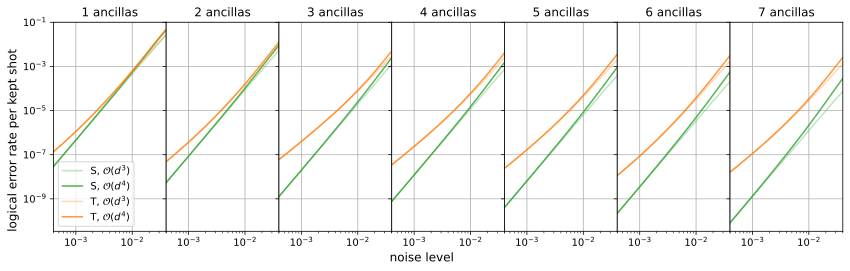

In [4]:
x_min, x_max = 4e-4, 4e-2
noise_levels = np.geomspace(x_min, x_max, 15)
color_map = {'S': 'tab:green', 'T': 'tab:orange'}
alpha_map = {3: 0.3, 4: 0.8}
y_mins, y_maxs = [], []
fig = plt.figure(figsize=(12, 4))
for ancilla_count, fault_combinator in fault_combinators.items():
    ax = plt.subplot(1, len(circuits), ancilla_count)
    for state, color in color_map.items():
        for max_order, alpha in alpha_map.items():
            y = [fault_combinator.error_rate_per_kept_shot(
                    kept_strings_dict[ancilla_count][state][:max_order+1],
                    noise_level=noise_level,
                ) for noise_level in noise_levels]
            plt.plot(
                noise_levels,
                y,
                marker=None,
                label=fr'{state}, $\mathcal{{O}}(d^{max_order})$',
                alpha=alpha,
                color=color,
            )
    plt.loglog()
    plt.title(f'{ancilla_count} ancillas')
    plt.grid(True, which='major')
    if ancilla_count == 1:
        plt.legend()
    else:
        ax.set_yticklabels([])
    plt.xlim(x_min, x_max)
    y_min, y_max = plt.ylim()
    y_mins.append(y_min)
    y_maxs.append(y_max)
for ancilla_count in fault_combinators.keys():
    plt.subplot(1, len(circuits), ancilla_count)
    plt.ylim(min(y_mins), max(y_maxs))
fig.supxlabel('noise level', y=0.07)
fig.supylabel('logical error rate per kept shot')
plt.tight_layout()
fig.subplots_adjust(wspace=0)

Text(0, 0.5, 'logical error rate per kept shot')

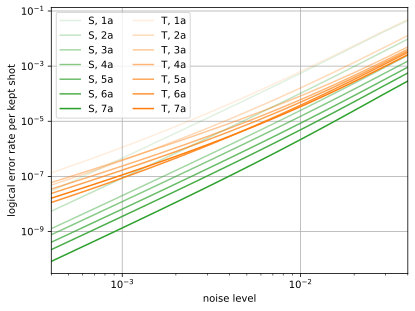

In [ ]:
x_min, x_max = 4e-4, 4e-2
noise_levels = np.geomspace(x_min, x_max, 15)
color_map = {'S': 'tab:green', 'T': 'tab:orange'}
# figure = plt.figure(figsize=(5, 5))
for state, color in color_map.items():
    for ancilla_count, fault_combinator in fault_combinators.items():
        y = [fault_combinator.error_rate_per_kept_shot(
                kept_strings_dict[ancilla_count][state],
                noise_level=noise_level,
        ) for noise_level in noise_levels]
        plt.plot(
            noise_levels,
            y,
            marker=None,
            label=fr'{state}, {ancilla_count}a',
            alpha=ancilla_count/7,
            color=color,
        )
plt.loglog()
plt.grid(True, which='major')
plt.legend(ncols=2)
plt.xlim(x_min, x_max)
plt.xlabel('noise level')
plt.ylabel('logical error rate per kept shot')
# plt.savefig(
#     'plots/ancilla_1_vs_6_vs_7.pdf',
#     bbox_inches='tight',
#     pad_inches=0.1,
# )

In [40]:
summaries = {ancilla_count: fault_combinator.summarize_contributions(kept_strings_dict[ancilla_count])
             for ancilla_count, fault_combinator in fault_combinators.items()}

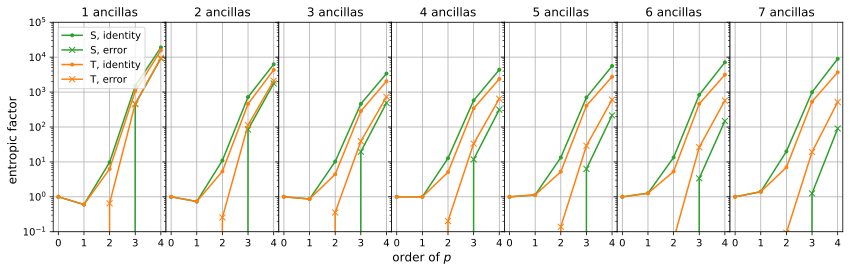

In [52]:
color_map = {'S': 'tab:green', 'T': 'tab:orange'}
marker_map = {0: '.', 1: 'x'}
label_map = {0: 'identity', 1: 'error'}
p_orders = range(5)
fig = plt.figure(figsize=(12, 4))
for ancilla_count, summary in summaries.items():
    ax = plt.subplot(1, 7, ancilla_count)
    for state, group in summary.groupby(level='cultivated_state'): # type: ignore
        state: str
        for col in (0, 1):
            plt.plot(
                group.index.get_level_values('order'),
                group[col],
                label=f'{state}, {label_map[col]}',
                color=color_map[state],
                marker=marker_map[col],
            )
    plt.yscale('log')
    plt.xticks(p_orders)
    plt.ylim(1e-1, 1e5)
    if ancilla_count == 1:
        plt.legend()
    else:
        ax.set_yticklabels([])
    plt.title(f'{ancilla_count} ancillas')
    plt.grid()
fig.supxlabel('order of $p$', y=0.07)
fig.supylabel('entropic factor')
plt.tight_layout()
plt.subplots_adjust(wspace=0)

Text(0.5, 0, 'order of $p$')

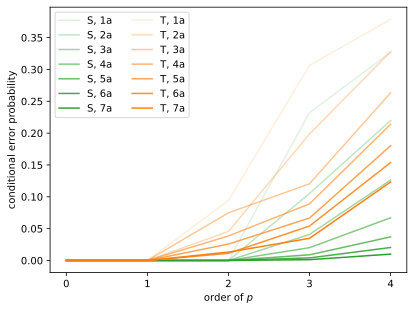

In [64]:
# f = plt.figure(figsize=(12, 3))
for state in PLOT_STATES:
    for ancilla_count, summary in summaries.items():
        group = summary.xs(state, level='cultivated_state')
        plt.plot(
            group.index.get_level_values('order'),
            group['conditional_probability'],
            label=f'{state}, {ancilla_count}a',
            color=color_map[state],
            marker=None,
            alpha=ancilla_count/7,
        )
    plt.xticks(p_orders)
plt.legend(ncol=2)
plt.ylabel('conditional error probability')
plt.xlabel('order of $p$')
# plt.yscale('log')

# Introspection

There are four order $p^2$ fault configurations in the original circuit that lead to logical error:

In [5]:
error_configs: list[frozenset[int]] = []
for (lv, configs) in kept_strings_dict[6]['T'][2].values():
    if lv.probability_of('Z'):
        error_configs += configs
error_configs

[frozenset({54, 150}),
 frozenset({65, 148}),
 frozenset({74, 146}),
 frozenset({111, 148})]

Visualize each configuration one by one, by inserting all the error events that can give rise to each fault in each configuration.
There will be a set of error events each with probability 0,
and another set of error events each with probability 0.1.
To construct an order $p^2$ _event_,
take one event from each set.

In [6]:
fault_combinators[6].visualize_fault_configurations(error_configs)

interactive(children=(BoundedIntText(value=0, description='configuration', max=3), Output()), _dom_classes=('w…

<function cliffordep.combinators.fault_combinator.FaultCombinator.visualize_fault_configurations.<locals>.f(configuration: int)>